Instrument Classification and Robustness Analysis Topic Research

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import librosa
import numpy as np  

In [3]:
#Data Path
data_home = "./mirdata/IRMAS-TrainingData"
y_audio_path = "./mirdata/IRMAS-TrainingData/cel/[cel][cla]0001__1.wav"

#load and test data
y, sr = librosa.load(y_audio_path,sr=44100)
#Audio sample in 44.1khz
print(y.shape, sr)



c:\Users\leo89\anaconda3\envs\mir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(132299,) 44100


C:\Users\leo89\AppData\Local\Temp\ipykernel_25660\3082606560.py:5: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)


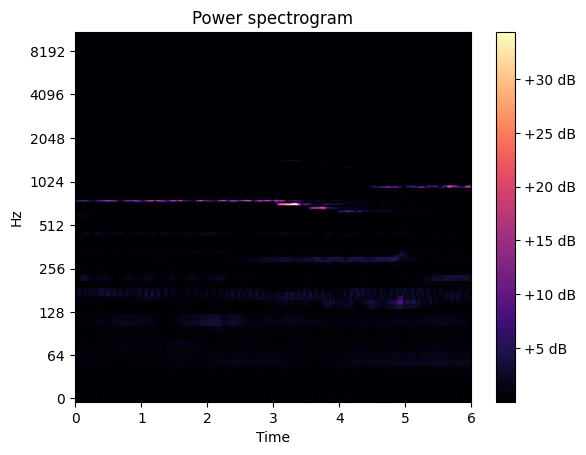

In [3]:
import matplotlib.pyplot as plt 
#audio spectrogram
Y = librosa.stft(y)
fig, ax = plt.subplots()
img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")




In [16]:
from dataset_preprocessing import create_dataset_csv
class_label = {'cel':0, 'pia':1, 'sax':2, 'flu':3, 'vio':4}

#load all data
df = create_dataset_csv(data_home)
#filter data by class label, only 5 classes are used in this project
df_filtered = df[df['label'].isin(class_label.keys())].copy()
df_filtered['label_id'] = df_filtered['label'].map(class_label)

print(df_filtered['label'].value_counts())

label
pia    721
sax    626
vio    580
flu    451
cel    388
Name: count, dtype: int64


In [5]:
import pandas as pd

save_path = "./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv"
df_filtered.to_csv(save_path, index=False, encoding='utf-8')

print("Filtered dataset saved to:", save_path)

Filtered dataset saved to: ./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv


Load CSV, starting from here.

In [3]:
import pandas as pd

save_path = "./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv"
#read the saved csv file to verify
df_dataset = pd.read_csv(save_path)
print(df_dataset.head())


                                           file_path label  label_id
0  ./mirdata/IRMAS-TrainingData\cel\038__[cel][no...   cel         0
1  ./mirdata/IRMAS-TrainingData\cel\038__[cel][no...   cel         0
2  ./mirdata/IRMAS-TrainingData\cel\038__[cel][no...   cel         0
3  ./mirdata/IRMAS-TrainingData\cel\041__[cel][no...   cel         0
4  ./mirdata/IRMAS-TrainingData\cel\041__[cel][no...   cel         0


In [10]:
from sklearn.utils import shuffle

#shuffle the dataset
train_df = shuffle(df_dataset)
print("Training set size:", len(train_df))
print("Train set",train_df.head())

Training set size: 2742
Train set                                               file_path label  label_id
2719  ./mirdata/IRMAS-TrainingData\vio\[vio][pop_roc...   vio         4
2720  ./mirdata/IRMAS-TrainingData\vio\[vio][pop_roc...   vio         4
240   ./mirdata/IRMAS-TrainingData\cel\[cel][jaz_blu...   cel         0
1069  ./mirdata/IRMAS-TrainingData\pia\[pia][cla]135...   pia         1
2524  ./mirdata/IRMAS-TrainingData\vio\[vio][jaz_blu...   vio         4


Text(0.5, 1.0, 'Distribution of Class Labels in Training Set')

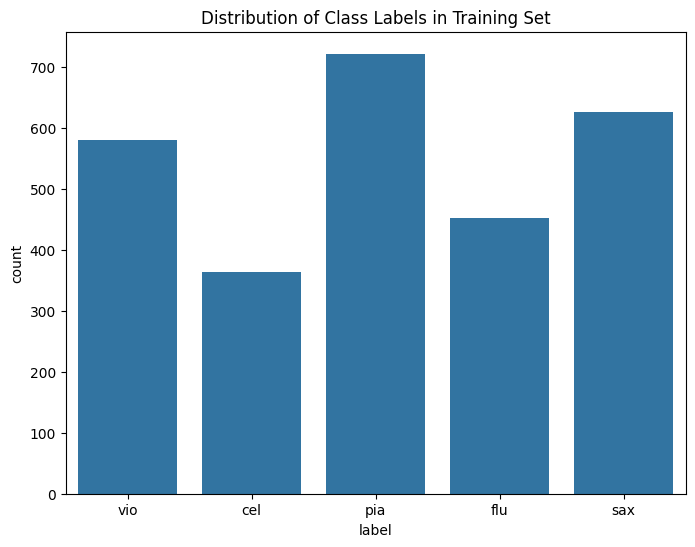

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt 

# Visualize the distribution of class labels in the training set
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=train_df)
plt.title('Distribution of Class Labels in Training Set')

In [14]:
y_train = train_df['label_id'].values
#y_test = test_df['label_id'].values
train_set = train_df['file_path'].values
#test_set = test_df['file_path'].values

#spilt to a smaller training set, set 200
#y_train = y_train[:200]
#train_set = train_set[:200]

#check whether the size match 
assert len(y_train) == len(train_set), "Trainset not aligned"
#assert len(y_test) == len(test_set), "Testset not aligned"

In [15]:
from dataset_preprocessing import convert_audio_to_mel_spectrogram

#convert audio to spectrogram for training
x_train = np.array(convert_audio_to_mel_spectrogram(train_set))
#x_test = np.array(convert_audio_to_mel_spectrogram(test_set))
print(x_train.shape)
#print(x_test.shape)


(2742, 128, 259)


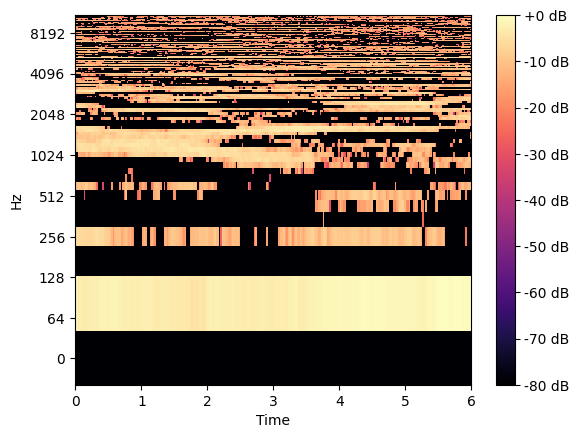

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
img = librosa.display.specshow(x_train[0],y_axis='log', x_axis='time', ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB")

SVM Data preprocessing below!

In [17]:
#reshape for svm, not for cnn
x_train_reshape = x_train.reshape((x_train.shape[0], 128*259))
#x_test_reshape = x_test.reshape((x_test.shape[0], 128*259))

In [19]:
from run_svm import train_svm
#run svm
clf = train_svm(x_train_reshape, y_train)

[LibSVM]

KeyboardInterrupt: 

Prepare the TEST SET

In [192]:
from run_svm import predict_svm
#predict the test set
y_predict = predict_svm(clf, x_test_reshape)
print(y_predict[0])


2


F1 and Accuracy Score Metric For SVM

In [20]:
from sklearn.metrics import f1_score, accuracy_score
print("f1 score for SVM:", format(f1_score(y_test, y_predict, average="macro")))
print("accuracy score for SVM:", format(accuracy_score(y_test, y_predict)))

NameError: name 'y_test' is not defined

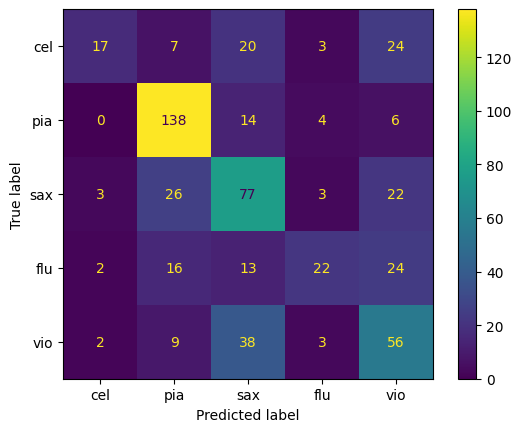

In [194]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svm_cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm,display_labels= ["cel", "pia", "sax", "flu", "vio"])
disp.plot()

Dataset spilt for CNN

In [21]:
from dataset_preprocessing import normalize_split_data

x_train_cnn, y_train_cnn, x_val_cnn, y_val_cnn = normalize_split_data(x_train, y_train, val_size=0.2)
print(x_train_cnn.shape)
print(y_train_cnn.shape)
print(x_val_cnn.shape)
print(y_val_cnn.shape)


(2194, 128, 259)
(2194,)
(548, 128, 259)
(548,)


In [28]:
from run_cnn import convolutional_model

input_shape = (128, 259, 1)
cnn_model = convolutional_model(input_shape=input_shape)
cnn_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 259, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 126, 257, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 257, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 128, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 126, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 126, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 60480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │       302,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,397 (1.17 MB)

 Trainable params: 307,301 (1.17 MB)

 Non-trainable params: 96 (384.00 B)

In [29]:
clf_cnn = cnn_model.fit(x_train_cnn, y_train_cnn, epochs=20, batch_size=32, validation_data=(x_val_cnn, y_val_cnn))

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.3455 - loss: 6.9275 - val_accuracy: 0.3047 - val_loss: 1.6467
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7402 - loss: 1.3982 - val_accuracy: 0.2354 - val_loss: 2.6370
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.8555 - loss: 0.7069 - val_accuracy: 0.2664 - val_loss: 3.3092
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9198 - loss: 0.3972 - val_accuracy: 0.3631 - val_loss: 3.0608
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9266 - loss: 0.3618 - val_accuracy: 0.4726 - val_loss: 2.5455
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9558 - loss: 0.2148 - val_accuracy: 0.4635 - val_loss: 3.9620
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9558 - loss: 0.2036 - val_accuracy: 0.4964 - val_loss: 3.8614
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9553 - loss: 0.2186 - val_accuracy: 0.5073 - v

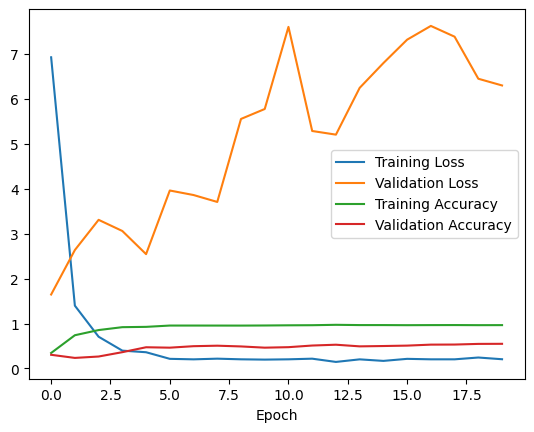

In [30]:
import matplotlib.pyplot as plt


plt.plot(clf_cnn.history['loss'], label='Training Loss')
plt.plot(clf_cnn.history['val_loss'], label='Validation Loss')
plt.plot(clf_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(clf_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
#plt.ylabel('Loss')
plt.legend()
plt.show()

In [220]:
from run_cnn import predict_cnn
y_predict_cnn = predict_cnn(cnn_model, x_test_cnn)
print(y_predict_cnn[0])
print(y_test_cnn[0])

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
0
3


In [221]:
from sklearn.metrics import f1_score, accuracy_score
print("f1 score for CNN:", format(f1_score(y_test_cnn, y_predict_cnn, average="macro")))
print("accuracy score for CNN:", format(accuracy_score(y_test_cnn, y_predict_cnn)))

f1 score for CNN: 0.4996356155866441
accuracy score for CNN: 0.5446265938069217


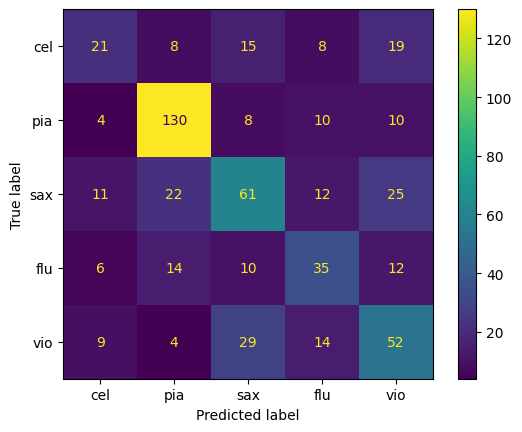

In [222]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cnn_cm = confusion_matrix(y_test_cnn, y_predict_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm,display_labels= ["cel", "pia", "sax", "flu", "vio"])
disp.plot()